# Phase 1 — Unaided two-armed bandit

Reproduces §1–§2 of [recommenders_v2.pdf](../latex/recommenders_v2.pdf): $n$ **independent** Beta-Bernoulli myopic Bayesian agents face a two-armed bandit with $p_A > p_B$. There is no recommender (Phase 1 uses `NullRecommender`).

This notebook estimates, for each of the three candidate definitions of $D_i$ implemented in [`model/discovery.py`](../model/discovery.py):
1. The per-agent discovery probability $\hat q = P(D_i)$.
2. The community discovery probability $\widehat{P(D)}$.
3. The independence-based prediction $1 - (1 - \hat q)^n$ for comparison.

The paper postulates $q \approx 0.05$, $n = 100$, hence $P(D) \approx 0.994$. Whichever (if any) of the three definitions lands near $q = 0.05$ under sensible parameters is the natural candidate for the paper's rigorous definition of $D_i$.

**Restart-and-Run-All-safe.** All heavy compute is wrapped in `%%time`; `tqdm` shows progress.

## Setup

This notebook is local-only (no Colab/Drive). It imports from `model/` in the parent paper folder.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PAPER_ROOT = Path.cwd().resolve().parent
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))
RESULTS_DIR = PAPER_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from model.bandit import ARM_A, ARM_B, BernoulliBandit
from model.discovery import (
    discovered_by_last_k,
    discovered_by_posterior_gap,
    discovered_by_posterior_probability,
)
from model.simulation import run_simulation


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/ignacio/anaconda3/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/ignacio/anaconda3/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  

AttributeError: _ARRAY_API not found

## Parameters

All tunable knobs in one cell. The paper fixes $n = 100$ but does not pin $p_A$, $p_B$, the priors, or the horizon $T$. Defaults below: a small-but-clear gap, a moderate horizon, and a tiered compute budget.

In [2]:
SMOKE_TEST = False        # True → tiny run for kernel-restart smoke tests

N_AGENTS = 100             # paper's n
N_STEPS  = 200             # horizon T per agent
P_A, P_B = 0.55, 0.45      # the two arms; p_A > p_B by construction
PRIOR    = None            # None → uniform Beta(1, 1) per arm
MASTER_SEED = 2026

# Discovery-definition parameters
LAST_K_WINDOW   = 20
GAP_DELTA       = 0.05
POSTERIOR_THR   = 0.95
POSTERIOR_SAMPS = 2_000

# Tiered compute budget: smoke → laptop
N_TRIALS = 20 if SMOKE_TEST else 200

print(f'SMOKE_TEST={SMOKE_TEST}  n_agents={N_AGENTS}  n_steps={N_STEPS}  n_trials={N_TRIALS}  seed={MASTER_SEED}')

SMOKE_TEST=False  n_agents=100  n_steps=200  n_trials=200  seed=2026


## Construct the bandit and spawn per-trial seeds

We derive per-trial seeds from `MASTER_SEED` via `SeedSequence.spawn` so trials are statistically independent **and** reproducible end-to-end.

In [3]:
BANDIT = BernoulliBandit(p_a=P_A, p_b=P_B)

ss = np.random.SeedSequence(MASTER_SEED)
trial_seeds = [int(s.generate_state(1)[0]) for s in ss.spawn(N_TRIALS)]

print(f'bandit: {BANDIT}')
print(f'first 3 trial seeds: {trial_seeds[:3]}')

bandit: BernoulliBandit(p_a=0.55, p_b=0.45)
first 3 trial seeds: [479243620, 454024514, 1818751028]


## Run trials

Each trial = one community of `N_AGENTS` agents running for `N_STEPS` steps. We store every trial's final state so the discovery definitions can be evaluated post-hoc without re-simulating.

In [4]:
%%time
results = [
    run_simulation(
        bandit=BANDIT,
        n_agents=N_AGENTS,
        n_steps=N_STEPS,
        prior_alpha_beta=PRIOR,
        seed=s,
    )
    for s in tqdm(trial_seeds, desc='trials')
]
assert len(results) == N_TRIALS
assert results[0].histories.shape == (N_AGENTS, N_STEPS, 2)
assert results[0].final_alpha_beta.shape == (N_AGENTS, 2, 2)

trials:   0%|          | 0/200 [00:00<?, ?it/s]

CPU times: user 2min 53s, sys: 1.72 s, total: 2min 55s
Wall time: 2min 58s


## Estimate $q = P(D_i)$ and $P(D)$ under each discovery definition

Per trial we compute a `(N_AGENTS,)` bool array of $D_i$ outcomes. Then:
- $\hat q$ = mean across all (trial, agent) pairs.
- $\widehat{P(D)}$ = fraction of trials with at least one $D_i$ true.
- $1 - (1 - \hat q)^n$ = the independence prediction §2 relies on.

In [5]:
%%time
posterior_rng = np.random.default_rng(MASTER_SEED + 1)

definitions = {
    f'last_k={LAST_K_WINDOW}':
        lambda h, ab: discovered_by_last_k(h, ab, k=LAST_K_WINDOW),
    f'posterior_gap>={GAP_DELTA}':
        lambda h, ab: discovered_by_posterior_gap(h, ab, delta=GAP_DELTA),
    f'P(p_A>p_B)>={POSTERIOR_THR}':
        lambda h, ab: discovered_by_posterior_probability(
            h, ab, threshold=POSTERIOR_THR, n_samples=POSTERIOR_SAMPS, rng=posterior_rng
        ),
}

def discovery_matrix(results, predicate):
    out = np.zeros((len(results), N_AGENTS), dtype=bool)
    for t, r in enumerate(results):
        for i in range(N_AGENTS):
            out[t, i] = predicate(r.histories[i], r.final_alpha_beta[i])
    return out

rows = []
for name, pred in definitions.items():
    D = discovery_matrix(results, pred)
    q_hat        = float(D.mean())
    PD_empirical = float(D.any(axis=1).mean())
    PD_indep     = 1 - (1 - q_hat) ** N_AGENTS
    rows.append(
        {
            'definition': name,
            'q_hat': q_hat,
            'P(D) empirical': PD_empirical,
            '1 - (1 - q_hat)^n': PD_indep,
        }
    )

summary = pd.DataFrame(rows).set_index('definition')
summary

CPU times: user 4.1 s, sys: 58.6 ms, total: 4.15 s
Wall time: 4.2 s


,q_hat,P(D) empirical,1 - (1 - q_hat)^n
definition,,,
last_k=20,0.66560,1.0,1.000000
posterior_gap>=0.05,0.63675,1.0,1.000000
P(p_A>p_B)>=0.95,0.05570,1.0,0.996757


## Sanity plot: posterior mean trajectories

Eight agents from the first trial. Black dashed lines mark the true $p_A$, $p_B$. If posteriors are not separating under our `(P_A, P_B)`, $\hat q$ for the gap and posterior-probability definitions will be near zero regardless of the threshold.

figure → results/phase1_posterior_trajectories.png


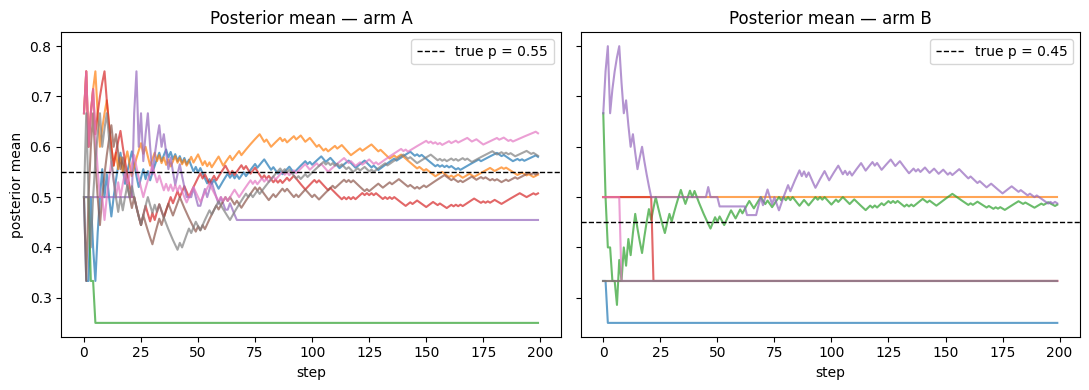

In [6]:
def trajectories(history, arm):
    alpha = 1.0
    beta = 1.0
    means = np.empty(len(history))
    for s, (arm_pulled, outcome) in enumerate(history):
        if arm_pulled == arm:
            if outcome == 1:
                alpha += 1
            else:
                beta += 1
        means[s] = alpha / (alpha + beta)
    return means

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sample = results[0]
for i in range(min(8, N_AGENTS)):
    h = sample.histories[i]
    axes[0].plot(trajectories(h, ARM_A), alpha=0.7)
    axes[1].plot(trajectories(h, ARM_B), alpha=0.7)
for ax, name, p in zip(axes, ['arm A', 'arm B'], [P_A, P_B]):
    ax.axhline(p, color='black', ls='--', lw=1, label=f'true p = {p}')
    ax.set_title(f'Posterior mean — {name}')
    ax.set_xlabel('step')
    ax.legend()
axes[0].set_ylabel('posterior mean')
plt.tight_layout()
fig_path = RESULTS_DIR / f'phase1_posterior_trajectories.png'
plt.savefig(fig_path, dpi=150)
print(f'figure → {fig_path.relative_to(PAPER_ROOT)}')
plt.show()

## Save

Persist the summary table as a timestamped CSV under [`results/`](../results/) so reruns under different parameters can be compared.

In [7]:
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
summary_path = RESULTS_DIR / f'phase1_summary_{stamp}.csv'
summary.to_csv(summary_path)
print(f'summary → {summary_path.relative_to(PAPER_ROOT)}')
print(f'figure  → {fig_path.relative_to(PAPER_ROOT)}')

summary → results/phase1_summary_20260528_102043.csv
figure  → results/phase1_posterior_trajectories.png


## What this shows

Phase 1 of the model is operational. Three candidate definitions of $D_i$ each give a concrete estimate of $\hat q$ under the chosen parameters; the gap between $\widehat{P(D)}$ (empirical) and $1 - (1 - \hat q)^n$ (independence prediction) should be near zero, since this regime is unaided and agents are genuinely independent.

## Next (Phase 2 — the recommender)

Implement a concrete `Recommender` subclass that:
1. Draws a common $Z \in \{G, F\}$ once per trial with $P(G) = 0.99$.
2. Returns per-step $R_i^t \in \{A, B\}$ with an explicit likelihood $P(R \mid \cdot)$, so [`BetaBernoulliAgent.apply_recommendation`](../model/agent.py) can perform the Bayesian conditioning step.
3. Reproduces §5: aided individual discovery $\approx 0.099$, aided community discovery $\approx 0.99$ (i.e. *down* from $\approx 0.994$ unaided).